# Batch Normalization 

---

## 1. Why Do We Use Batch Normalization?

Deep neural networks often suffer from:

- Unstable gradient magnitudes  
- Sensitivity to initialization  
- Sensitivity to learning rate  
- Activation scale explosion or collapse  
- Poorly conditioned loss landscapes  

Batch Normalization (BN) stabilizes training by **normalizing intermediate representations** inside the network.

Instead of allowing each layer to produce arbitrarily scaled outputs:

$$
z = Wx + b
$$

we enforce controlled statistics during training.

This improves optimization geometry and enables larger learning rates.

---

## 2. Mathematical Definition

Before introducing the equations, it is important to understand **why we normalize using batch statistics**.

During training, each layer receives inputs whose distribution keeps changing as previous layers update their weights. This causes:

- Fluctuating activation scales  
- Saturation of nonlinearities (e.g., tanh, sigmoid)  
- Exploding or vanishing gradients  
- Rapid changes in curvature  

Instead of trying to control the weights directly, Batch Normalization controls the **distribution of activations**.

The key idea is:

> If we keep the intermediate representations centered and with controlled variance, optimization becomes more stable.

Why use **batch statistics**?

Because we do not know the true population distribution of activations during training.  
The mini-batch provides a tractable, unbiased estimator of:

- Mean  
- Variance  

Thus, each forward pass dynamically normalizes activations relative to the current training distribution.

---

Let:

$$
z_i = W x_i + b
$$

for a mini-batch of size $m$.

### Step 1 — Batch Statistics

$$
\mu_B = \frac{1}{m} \sum_{i=1}^m z_i
$$

$$
\sigma_B^2 = \frac{1}{m} \sum_{i=1}^m (z_i - \mu_B)^2
$$

These estimate the first and second moments of the activation distribution.

---

### Step 2 — Normalize

$$
\hat{z}_i = \frac{z_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
$$

Now:

$$
\mathbb{E}[\hat{z}] = 0
$$

$$
\mathrm{Var}(\hat{z}) = 1
$$

This removes arbitrary scale and shift from the representation.

---

### Step 3 — Re-scale and Shift

After normalization we obtain:

$$
\hat{z}_i = \frac{z_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
$$

which enforces:

$$
\mathbb{E}[\hat{z}] = 0, \quad \mathrm{Var}(\hat{z}) = 1
$$

However, forcing every activation to always have zero mean and unit variance could overly restrict the layer.

To restore flexibility, BatchNorm introduces two learnable parameters per feature:

$$
y_i = \gamma \hat{z}_i + \beta
$$

where:

- $\gamma$ controls the **scale**
- $\beta$ controls the **shift**

#### Why is this necessary?

1. **Recovering Representational Power**

If the optimal representation requires:
- A larger variance → $\gamma$ will increase it.
- A shifted mean → $\beta$ will translate it.

Thus, BN does not constrain what the network can represent, it only reparameterizes how it is optimized.

2. **Decoupling Scale from Direction**

Before BN, scaling the weights changes the activation magnitude.

With BN:

- The direction of $W$ determines the feature.
- The magnitude is absorbed by normalization.
- $\gamma$ becomes the only parameter controlling output scale.

This separates:
- Feature learning (via $W$ direction)
- Feature scaling (via $\gamma$)

3. **Geometric Interpretation**

Normalization projects activations onto a standardized manifold (zero mean, unit variance). The affine transform:

$$
\gamma \hat{z} + \beta
$$

then allows the model to learn the optimal point on that manifold without reintroducing unstable scaling dynamics in the weights.


In summary:

- Normalization stabilizes optimization.
- $\gamma$ and $\beta$ preserve expressivity.
- The layer becomes scale-invariant in $W$, but still fully learnable.

--- 

## 3. Geometric Interpretation

Without BN:

$$
z = Wx
$$

If we scale weights:

$$
W' = cW
$$

then:

$$
z' = cWx
$$

This scaling affects:

- Activation magnitudes  
- Gradient magnitudes  
- Curvature of the loss surface  

The loss becomes highly sensitive to weight norms.

---

### Scale Invariance with BN

With BN:

$$
\hat{z} = \frac{Wx - \mu}{\sigma}
$$

If:

$$
W' = cW
$$

both numerator and denominator scale by $c$, so:

$$
\hat{z} \text{ remains approximately invariant to weight scale}
$$

### Geometric Consequence

BatchNorm removes dependence on the radial direction of $W$.

This:

- Reduces anisotropy
- Improves conditioning
- Makes valleys more spherical
- Aligns gradient directions better

---

## 4. Why BN Allows Large Learning Rates

Gradient descent updates parameters as:

$$
W_{t+1} = W_t - \eta \nabla L(W_t)
$$

The stability of this update depends on the curvature of the loss surface.
If the loss is locally approximated by a quadratic:

$$
L(W) \approx \frac{1}{2} W^T H W
$$

then convergence requires:

$$
\eta < \frac{2}{\lambda_{\max}(H)}
$$

where:

- $H$ is the Hessian  
- $\lambda_{\max}(H)$ is its largest eigenvalue  

Thus, the maximum stable learning rate is inversely proportional to the sharpest curvature direction.


### Problem Without BatchNorm

Without BN:

1. Scaling weights increases activation magnitude.
2. Large activations can saturate nonlinearities.
3. Saturation produces large curvature variations.
4. The Hessian spectrum becomes highly spread:

$$
\lambda_{\max} \gg \lambda_{\min}
$$

This leads to:

- High anisotropy  
- Large condition number  
- Small allowable learning rate  

Large $\eta$ causes:

- Oscillations along sharp directions  
- Divergence  
- Exploding gradients  

### How BatchNorm Changes This
#### 1. Scale Invariance

If:

$$
W' = cW
$$

then:

$$
\hat{z}(W') \approx \hat{z}(W)
$$

The loss becomes approximately invariant to radial scaling of $W$.
This removes one source of extreme curvature growth.

#### 2. Gradient Normalization Effect

Because normalization divides by the batch standard deviation, the backward pass includes terms proportional to:

$$
\frac{1}{\sigma_B}
$$

If activations grow, $\sigma_B$ grows as well, which reduces effective gradient magnitude.
This acts as an adaptive step-size control mechanism.

#### 3. Hessian Spectrum Compression

Empirically and theoretically, BN:

- Reduces $\lambda_{\max}(H)$  
- Compresses eigenvalue spread  
- Reduces condition number ($\kappa$), deffined as:

$$
\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}
$$

Where:

- $\lambda_{\max}(H)$ is the largest eigenvalue of the Hessian  
- $\lambda_{\min}(H)$ is the smallest positive eigenvalue  


Lower $\kappa$ ⇒ more isotropic curvature.
This allows:

$$
\eta_{BN} > \eta_{noBN}
$$

without instability.

---

## 5. BN as Implicit Regularization

Because batch statistics depend on each mini-batch:

$$
\mu_B, \sigma_B
$$

are stochastic.

This introduces noise into the forward pass.

Consequences:

- Stochastic smoothing of the loss
- Implicit ensemble effect
- Improved generalization

Even without dropout.

---

## 6. Example

To illustrate the optimization effects of Batch Normalization, we train a small neural network to approximate:

$$
f(x) = \sin(z_1) + \tanh(z_2)
$$

where:

$$
z_1 = x W_1
$$

$$
z_2 = x W_2
$$

This creates a controlled setting with:

- Oscillatory curvature (from $\sin$)  
- Saturation effects (from $\tanh$)  
- Multiple sharp and flat regions  
- Loss landscape with high non-convex and anisotropic structure

### Experimental Setup

We compare training dynamics **with and without BatchNorm** under different learning rates:

$$
\eta \in \{0.001, 0.01, 0.5\}
$$

The objective is to observe:

- Stability of training  
- Loss smoothness  
- Gradient norm behavior  
- Sensitivity to learning rate 

In [98]:
import math
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
rng = np.random.default_rng(42)

input_size = 10000
features_size = 50

X = torch.randn(input_size, features_size)
true_w1 = torch.randn(features_size, 1)
true_w2 = torch.randn(features_size, 1)

logits = torch.sin(X @ true_w1) + 0.5 * torch.tanh(X @ true_w2)
y = (logits > 0).float()

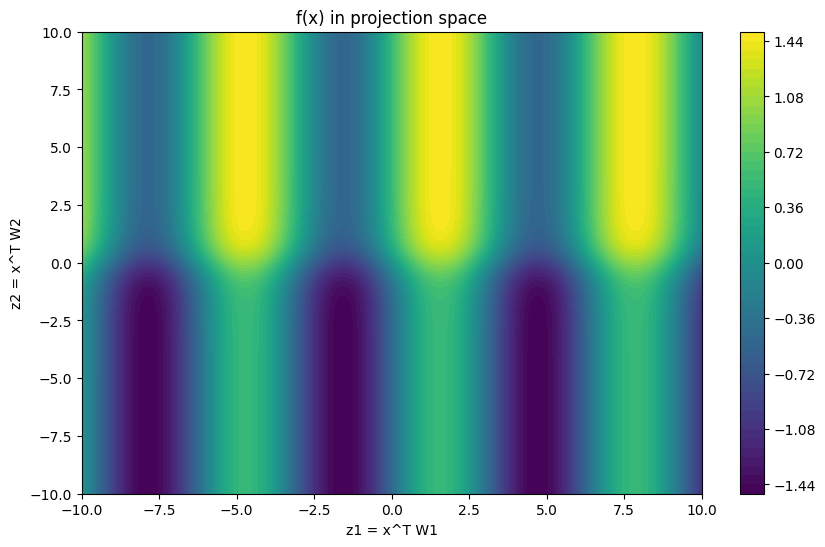

In [99]:
z1 = np.linspace(-10, 10, 200)
z2 = np.linspace(-10, 10, 200)
Z1, Z2 = np.meshgrid(z1, z2)
F = np.sin(Z1) + 0.5 * np.tanh(Z2)

plt.figure(figsize=(10, 6))
plt.contourf(Z1, Z2, F, levels=50)
plt.xlabel("z1 = x^T W1")
plt.ylabel("z2 = x^T W2")
plt.title("f(x) in projection space")
plt.colorbar()
plt.show()

In [100]:
width = 50
depth = 10

output_bias   = nn.Parameter(torch.zeros(1))
output_weight = nn.Parameter(torch.randn(width, 1))
bias = nn.ParameterList([nn.Parameter(torch.zeros(width)) for _ in range(depth - 1)])
weights = nn.ParameterList([nn.Parameter(torch.randn(width, width)) for _ in range(depth -1)])

In [101]:
def train_model(model, X, y, epochs=100, lr=0.001, verbose=10):
    
    model.train()  # Flags train attribute on model
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    
    losses = []

    for epoch in range(epochs):
        
        optimizer.zero_grad()
        
        outputs = model(X)         
        loss = criterion(outputs, y)
        
        loss.backward()             
        optimizer.step()        
        
        losses.append(loss.item())
        if epoch % verbose == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.4f}")
        
    return losses

In [102]:
class PlainMLP(nn.Module):
    def __init__(self, weights, bias, output_weight, output_bias, width=50, depth=10):
        super().__init__()
        
        self.depth = depth
        self.width = width
        
        self.bias = bias
        self.weights = weights
        self.output_bias = output_bias 
        self.output_weight = output_weight
        
    def forward(self, x):
        for d in range(self.depth - 1):
            x = x @ self.weights[d] + self.bias[d]
            x = torch.sigmoid(x)
        x = x @ self.output_weight + self.output_bias
        return x
    

In [103]:
learning_rates = [.001, .01, .5]
plain_mlp_losses = []

for lr in learning_rates:
    print(f'\nLearning rate: {lr}')
    model_plain = PlainMLP(weights, bias, output_weight, output_bias)
    loss = train_model(model_plain, X, y, lr=lr)
    plain_mlp_losses.append(loss)


Learning rate: 0.001
Epoch 0 | Loss: 0.7712
Epoch 10 | Loss: 0.6969
Epoch 20 | Loss: 0.6936
Epoch 30 | Loss: 0.6912
Epoch 40 | Loss: 0.6889
Epoch 50 | Loss: 0.6866
Epoch 60 | Loss: 0.6838
Epoch 70 | Loss: 0.6800
Epoch 80 | Loss: 0.6754
Epoch 90 | Loss: 0.6698

Learning rate: 0.01
Epoch 0 | Loss: 0.6633
Epoch 10 | Loss: 0.7140
Epoch 20 | Loss: 0.6871
Epoch 30 | Loss: 0.6834
Epoch 40 | Loss: 0.6624
Epoch 50 | Loss: 0.6364
Epoch 60 | Loss: 0.6097
Epoch 70 | Loss: 0.5814
Epoch 80 | Loss: 0.5474
Epoch 90 | Loss: 0.5609

Learning rate: 0.5
Epoch 0 | Loss: 0.5023
Epoch 10 | Loss: 1.5438
Epoch 20 | Loss: 0.7295
Epoch 30 | Loss: 0.8057
Epoch 40 | Loss: 0.7414
Epoch 50 | Loss: 0.7064
Epoch 60 | Loss: 0.6931
Epoch 70 | Loss: 0.6954
Epoch 80 | Loss: 0.6930
Epoch 90 | Loss: 0.6932


In [104]:
class BatchNormalizationMLP(nn.Module):

    def __init__(self, weights, bias, output_weight, output_bias, width=50, depth=10, momentum = 0.1, scaling_factor=.3):
        super().__init__()
        
        self.depth = depth
        self.width = width
        self.epslon = 1e-5
        self.momentum = momentum
        self.output_bias = output_bias
        self.output_weight = output_weight
        self.scaling_factor = scaling_factor
        self.bias = bias
        self.beta = nn.ParameterList([nn.Parameter(torch.zeros(width)) for _ in range(depth - 1)])
        self.gamma = nn.ParameterList([nn.Parameter(torch.ones(width)) for _ in range(depth - 1)])
        self.weights = weights

        self.running_mean = []
        self.running_var = []

        for d in range(depth - 1):
            self.register_buffer(f"running_mean_{d}", torch.zeros(width))
            self.register_buffer(f"running_var_{d}", torch.ones(width))
        
    def forward(self, x):
        for d in range(self.depth - 1):
            x = x @ self.weights[d] + self.bias[d]
            
            if self.training:
                mean = x.mean(dim=0)
                var  = x.var(dim=0, unbiased=False)

                running_mean = getattr(self, f"running_mean_{d}")
                running_var  = getattr(self, f"running_var_{d}")

                running_mean.mul_(1 - self.momentum).add_(self.momentum * mean)
                running_var.mul_(1 - self.momentum).add_(self.momentum * var)

            else:
                mean = getattr(self, f"running_mean_{d}")
                var  = getattr(self, f"running_var_{d}")
                
            x_hat = (x - mean) / torch.sqrt(var + self.epslon)
            
            x = self.scaling_factor * (self.gamma[d] * x_hat + self.beta[d])
            x = torch.sigmoid(x)

        x = x @ self.output_weight + self.output_bias
        return x
    


In [118]:
bn_mlp_losses = []

for lr in learning_rates:
    print(f'\nLearning rate: {lr}')
    model_bn = BatchNormalizationMLP(weights, bias, output_weight, output_bias, momentum=.5, scaling_factor=1.5)
    loss = train_model(model_bn, X, y, lr=lr)
    bn_mlp_losses.append(loss)



Learning rate: 0.001
Epoch 0 | Loss: 1.7488
Epoch 10 | Loss: 1.5630
Epoch 20 | Loss: 1.3883
Epoch 30 | Loss: 1.2287
Epoch 40 | Loss: 1.0881
Epoch 50 | Loss: 0.9691
Epoch 60 | Loss: 0.8730
Epoch 70 | Loss: 0.7996
Epoch 80 | Loss: 0.7471
Epoch 90 | Loss: 0.7122

Learning rate: 0.01
Epoch 0 | Loss: 0.9250
Epoch 10 | Loss: 0.6924
Epoch 20 | Loss: 0.6568
Epoch 30 | Loss: 0.6464
Epoch 40 | Loss: 0.6419
Epoch 50 | Loss: 0.6383
Epoch 60 | Loss: 0.6351
Epoch 70 | Loss: 0.6319
Epoch 80 | Loss: 0.6287
Epoch 90 | Loss: 0.6255

Learning rate: 0.5
Epoch 0 | Loss: 0.6958
Epoch 10 | Loss: 0.9504
Epoch 20 | Loss: 0.6942
Epoch 30 | Loss: 0.6331
Epoch 40 | Loss: 0.6152
Epoch 50 | Loss: 0.5867
Epoch 60 | Loss: 0.5687
Epoch 70 | Loss: 0.5495
Epoch 80 | Loss: 0.5292
Epoch 90 | Loss: 0.5398


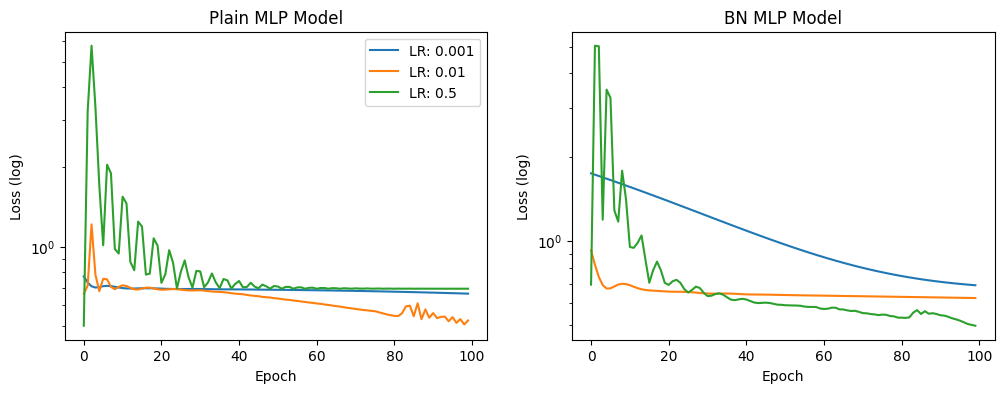

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  

for i in range(len(plain_mlp_losses)):
    axes[0].plot(range(len(plain_mlp_losses[i])), plain_mlp_losses[i], label=f'LR: { str(learning_rates[i]) }')

for i in range(len(bn_mlp_losses)):
    axes[1].plot(range(len(bn_mlp_losses[i])), bn_mlp_losses[i], label=f'LR: { str(learning_rates[i]) }')

axes[0].set_title("Plain MLP Model")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (log)")
axes[0].set_yscale('log')

axes[1].set_title("BN MLP Model")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (log)")
axes[1].set_yscale('log')

axes[0].legend()
plt.show()

In [ ]:
lst = np.array([])
l = [lst.h(1/.00001) ]

In [136]:
import numpy as np

lst = np.array([])
lst = [np.hstack([lst, [1 / .01]]) for i in range(100)]
np.prod(lst)

np.float64(1e+200)

In [135]:
1/.0000001

10000000.0